In [3]:
library(tidyverse)

# ---- paths (adjust to your wd) ----
bco_dir    <- "../BCO-DMO"
proc_csv   <- "../processed/HPLC_interpolated_sizes.csv"
pre_cutoff <- as.Date("2005-01-01")

# 1. The offending dates: size fractions present, Tot_Chl_a absent, pre-collapse
fin <- read.csv(proc_csv) %>% mutate(date = as.Date(date))
bad <- fin %>%
  filter(!is.na(micro), is.na(Tot_Chl_a), date < pre_cutoff) %>%
  arrange(date)
cat(sprintf("Pre-era dates with size fractions but NO Tot_Chl_a: %d\n", nrow(bad)))
print(bad %>% select(date, source, micro, nano, pico), row.names = FALSE)
bad_months <- format(bad$date, "%m-%Y")

# 2. Re-read the 4 labs WITHOUT NA conversion -> literal strings
files <- c(BBRS="hplc_bbrs.csv", MOTE="hplc_mote.csv",
           HPL="hplc_hpl.csv",  NGSFC="hplc_ngsfc.csv")
keep  <- c("Date","depth","Tot_Chl_a","TChl","Tot_Chl_b","Fuco","Zea")
raw_lit <- imap_dfr(files, function(fn, lab){
  d <- read.csv(file.path(bco_dir, fn), colClasses = "character",
                na.strings = character(0), check.names = FALSE)
  d <- d[, intersect(keep, names(d)), drop = FALSE]
  for(m in setdiff(keep, names(d))) d[[m]] <- NA_character_   # column absent in this lab
  d$source <- lab; d
}) %>%
  mutate(date  = as.Date(Date, "%Y%m%d"),
         depth = as.numeric(depth),
         month = format(date, "%m-%Y")) %>%
  filter(month %in% bad_months)

# 3. classify a literal cell
classify <- function(x){
  xt  <- trimws(x); num <- suppressWarnings(as.numeric(xt))
  case_when(is.na(x) | xt == ""      ~ "blank",
            tolower(xt) == "nd"      ~ "nd",
            !is.na(num) & num <  0   ~ "neg_sentinel",
            !is.na(num) & num >= 0   ~ "value",
            TRUE                     ~ paste0("other:", xt))
}

# 4. per-depth literal dump per offending date (0-60 m)
for(m in bad_months){
  cat("\n==================  ", m, "  ==================\n")
  raw_lit %>% filter(month == m, depth <= 60) %>% arrange(depth, source) %>%
    transmute(date, depth, source,
              Tot_Chl_a, st_TCA = classify(Tot_Chl_a),
              TChl,      st_TChl = classify(TChl),
              Fuco,      st_Fuco = classify(Fuco)) %>%
    as.data.frame() %>% print(row.names = FALSE)
}

Pre-era dates with size fractions but NO Tot_Chl_a: 9
       date source     micro       nano       pico
 2000-11-03   MOTE 0.4383484 0.16681045 0.39484115
 2000-12-05   MOTE 0.5400023 0.17046147 0.28953620
 2001-01-11   MOTE 0.8748072 0.05057798 0.07461481
 2001-02-18   MOTE 0.9217302 0.03447919 0.04379065
 2001-03-14   MOTE 0.9330999 0.03235564 0.03454445
 2001-04-04   MOTE 0.6529074 0.15852222 0.18857043
 2001-05-05   MOTE 0.2248581 0.26732017 0.50782170
 2001-06-10   MOTE 0.3807920 0.26684374 0.35236425
 2001-07-10   MOTE 0.5603517 0.30799049 0.13165786

==================   11-2000   ==================
       date depth source Tot_Chl_a st_TCA TChl st_TChl  Fuco st_Fuco
 2000-11-03     2   MOTE        nd     nd   nd      nd 0.004   value
 2000-11-03     7   MOTE        nd     nd   nd      nd 0.004   value
 2000-11-03    16   MOTE        nd     nd   nd      nd 0.003   value
 2000-11-03    25   MOTE        nd     nd   nd      nd 0.002   value
 2000-11-03    35   MOTE        nd     n

In [4]:
library(oce)
# 5. per-date summary: Tot_Chl_a status vs DP pigment presence
summ <- raw_lit %>%
  mutate(tca = classify(Tot_Chl_a), tch = classify(TChl), fuc = classify(Fuco)) %>%
  group_by(month) %>%
  summarise(
    sources            = paste(sort(unique(source)), collapse="+"),
    n_depth_0_50       = n_distinct(depth[depth <= 50]),
    TCA_value          = sum(tca == "value"),
    TCA_value_0_50     = sum(tca == "value" & depth <= 50),
    TCA_nd             = sum(tca == "nd"),
    TCA_neg            = sum(tca == "neg_sentinel"),
    TCA_blank          = sum(tca == "blank"),
    TChl_value_0_50    = sum(tch == "value" & depth <= 50),
    Fuco_value_0_50    = sum(fuc == "value" & depth <= 50),
    shallowest_TCA     = ifelse(any(tca=="value"), min(depth[tca=="value"]), NA),
    deepest_TCA        = ifelse(any(tca=="value"), max(depth[tca=="value"]), NA),
    .groups="drop") %>%
  mutate(verdict = case_when(
    TCA_value == 0 & TChl_value_0_50 > 0 ~ "absent as Tot_Chl_a; TChl carries it",
    TCA_value == 0                       ~ "completely absent (no numeric TCA anywhere)",
    TCA_value_0_50 == 0                  ~ "present only below 50 m",
    TRUE                                 ~ "present 0-50 m -> interp/threshold issue"))
cat("\n--- Per-date verdict ---\n"); print(as.data.frame(summ), row.names = FALSE)

# 6. trace the actual pipeline: would Tot_Chl_a survive the unesco interp + noofNA=10?
hplc <- bind_rows(lapply(files, function(fn)
          read.csv(file.path(bco_dir, fn), na.strings = "nd")))
hplc$date <- as.Date(as.character(hplc$Date), "%Y%m%d")
hplc$Tot_Chl_a[hplc$Tot_Chl_a < 0] <- NA
mesh <- hplc %>% filter(format(date,"%m-%Y") %in% bad_months) %>%
  group_by(date, depth) %>%
  summarise(Tot_Chl_a = mean(Tot_Chl_a, na.rm = TRUE), .groups = "drop")

trace <- mesh %>% group_by(date) %>% group_modify(function(df, key){
  zz <- 0:50
  d <- df$depth[!is.na(df$Tot_Chl_a)]; v <- df$Tot_Chl_a[!is.na(df$Tot_Chl_a)]
  yi <- if(length(d) == 0) rep(NA, length(zz)) else oceApprox(d, v, zz, "unesco")
  tibble(n_raw_depths_TCA   = length(d),
         n_NA_in_0_50       = sum(is.na(yi)),
         dropped_noofNA10   = sum(is.na(yi)) >= 10,
         integrated_if_kept = mean(yi, na.rm = TRUE) * 50)
}) %>% ungroup()
cat("\n--- Interpolation trace ---\n"); print(as.data.frame(trace), row.names = FALSE)

Lade nötiges Paket: gsw




--- Per-date verdict ---
   month sources n_depth_0_50 TCA_value TCA_value_0_50 TCA_nd TCA_neg TCA_blank
 01-2001    MOTE            5         0              0      8       0         0
 02-2001    MOTE            5         0              0      8       0         0
 03-2001    MOTE            5         0              0      8       0         0
 04-2001    MOTE            5         0              0      8       0         0
 05-2001    MOTE            5         0              0      8       0         0
 06-2001    MOTE            5         0              0      8       0         0
 07-2001    MOTE            5         0              0      8       0         0
 11-2000    MOTE            5         0              0      8       0         0
 12-2000    MOTE            5         0              0      8       0         0
 TChl_value_0_50 Fuco_value_0_50 shallowest_TCA deepest_TCA
               0               5             NA          NA
               0               5             NA       

In [6]:
library(tidyverse)
files <- c(BBRS="hplc_bbrs.csv", MOTE="hplc_mote.csv",
           HPL="hplc_hpl.csv",  NGSFC="hplc_ngsfc.csv")
hplc <- imap_dfr(files, function(fn, lab){
  d <- read.csv(file.path("../BCO-DMO", fn), na.strings = "nd"); d$source <- lab; d
})
hplc$date <- as.Date(as.character(hplc$Date), "%Y%m%d")
pig <- c("Fuco","Perid","Allo","But_fuco","Hex_fuco","Zea","Tot_Chl_b","Tot_Chl_a")
hplc[pig][hplc[pig] < 0] <- NA

# (a) Is TChla a MOTE-only gap? availability by source x era
hplc %>% mutate(era = ifelse(date < as.Date("2005-01-01"),"pre","post")) %>%
  group_by(source, era) %>%
  summarise(n_rows = n(),
            TChla_present = sum(!is.na(Tot_Chl_a)),
            frac = round(mean(!is.na(Tot_Chl_a)), 2), .groups="drop") %>%
  as.data.frame() %>% print(row.names = FALSE)

# (b) Calibrate DP2 -> TChla on rows where both exist (native depths)
cal <- hplc %>%
  mutate(across(all_of(pig[1:7]), ~replace_na(., 0)),   # DP uses zero-fill convention
         DP2 = 1.41*Fuco + 1.41*Perid + 0.60*Allo + 0.35*But_fuco +
               1.27*Hex_fuco + 0.86*Zea + 1.01*Tot_Chl_b) %>%
  filter(!is.na(Tot_Chl_a), DP2 > 0.001)
fit_free <- lm(Tot_Chl_a ~ DP2, data = cal)
fit_orig <- lm(Tot_Chl_a ~ DP2 + 0, data = cal)
cat(sprintf("\nn=%d  free: slope=%.3f int=%.3f R2=%.3f | origin: slope=%.3f R2=%.3f\n",
            nrow(cal), coef(fit_free)[2], coef(fit_free)[1], summary(fit_free)$r.squared,
            coef(fit_orig)[1], summary(fit_orig)$r.squared))

 source  era n_rows TChla_present frac
   BBRS  pre    246           244 0.99
    HPL post    478           478 1.00
   MOTE  pre    307           209 0.68
  NGSFC post    567           567 1.00

n=1498  free: slope=4.361 int=-1.167 R2=0.547 | origin: slope=3.882 R2=0.517


In [8]:
library(tidyverse)
files <- c(BBRS="hplc_bbrs.csv", MOTE="hplc_mote.csv",
           HPL="hplc_hpl.csv",  NGSFC="hplc_ngsfc.csv")
hplc <- imap_dfr(files, function(fn, lab){
  d <- read.csv(file.path("../BCO-DMO", fn), na.strings = "nd"); d$source <- lab; d
})
hplc$date <- as.Date(as.character(hplc$Date), "%Y%m%d")
pig7 <- c("Fuco","Perid","Allo","But_fuco","Hex_fuco","Zea","Tot_Chl_b")
hplc[c(pig7,"Tot_Chl_a")][hplc[c(pig7,"Tot_Chl_a")] < 0] <- NA

# integrated-proxy: 0-50 m mean per cruise (approximates the integrated metric)
agg <- hplc %>%
  mutate(across(all_of(pig7), ~replace_na(., 0)),
         DP2 = 1.41*Fuco + 1.41*Perid + 0.60*Allo + 0.35*But_fuco +
               1.27*Hex_fuco + 0.86*Zea + 1.01*Tot_Chl_b) %>%
  filter(depth <= 50) %>%
  group_by(source, date) %>%
  summarise(TChla = mean(Tot_Chl_a, na.rm = TRUE),
            DP2   = mean(DP2,       na.rm = TRUE),
            n_tca = sum(!is.na(Tot_Chl_a)), .groups = "drop")

# MOTE date-level: fully-missing vs partial vs complete TChla cruises
agg %>% filter(source=="MOTE") %>%
  mutate(cls = case_when(n_tca==0 ~ "all_nd", n_tca<5 ~ "partial", TRUE ~ "complete")) %>%
  count(cls) %>% as.data.frame() %>% print(row.names = FALSE)

# calibrations on cruise-integrated values
fit_report <- function(df, tag){
  d <- df %>% filter(n_tca > 0, DP2 > 0.001, is.finite(TChla))
  m <- lm(TChla ~ DP2, data = d)
  cat(sprintf("%-12s n=%3d  slope=%.3f  int=%.3f  R2=%.3f\n",
              tag, nrow(d), coef(m)[2], coef(m)[1], summary(m)$r.squared))
  m
}
cat("\n--- integrated 0-50m calibrations ---\n")
m_glob <- fit_report(agg, "global")
m_mote <- fit_report(agg %>% filter(source=="MOTE"), "MOTE-only")

# predicted TChla for the 9 missing MOTE cruises, from MOTE's own calibration
miss <- agg %>% filter(source=="MOTE", n_tca==0, DP2 > 0.001)
miss$TChla_pred_MOTE <- predict(m_mote, miss)
cat("\n--- predicted fills for the 9 MOTE cruises ---\n")
print(miss %>% select(date, DP2, TChla_pred_MOTE) %>% arrange(date), row.names = FALSE)

      cls  n
   all_nd  9
 complete 24
  partial  5

--- integrated 0-50m calibrations ---
global       n=167  slope=2.176  int=-0.303  R2=0.419
MOTE-only    n= 29  slope=1.376  int=-0.033  R2=0.961

--- predicted fills for the 9 MOTE cruises ---
# A tibble: 9 × 3
  date         DP2 TChla_pred_MOTE
  <date>     <dbl>           <dbl>
1 2000-11-03 0.083          0.0808
2 2000-12-05 0.894          1.20  
3 2001-01-11 1.75           2.37  
4 2001-02-18 1.82           2.46  
5 2001-03-14 3.11           4.24  
6 2001-04-04 0.579          0.763 
7 2001-05-05 0.378          0.487 
8 2001-06-10 0.192          0.231 
9 2001-07-10 0.255          0.318 


In [10]:
library(tidyverse)
source("depth_profile_data.R")
bco_dir <- "../BCO-DMO"

profile_data <- load_profile_data()
proxy_model  <- fit_euphotic_proxy(profile_data$scenario,
                                   niskin_profiles = profile_data$niskin,
                                   model_type = "isotherm_chl")

# monthly dynamic cutoff, exactly as get_full_scenario_data(dynamic) builds it (:992-1009)
cutoff_monthly <- proxy_model$predictions %>%
  mutate(time_month = format(date, "%m-%Y")) %>%
  group_by(time_month) %>%
  summarise(depth_cutoff = mean(euphotic_depth_best, na.rm = TRUE), .groups = "drop") %>%
  mutate(depth_cutoff = ifelse(is.nan(depth_cutoff), NA_real_, depth_cutoff))

# per-cruise integration to that cutoff (mirrors :1038-1061)
pig <- c("Fuco","Perid","Allo","But_fuco","Hex_fuco","Zea","Tot_Chl_b","Tot_Chl_a")
hplc_int <- profile_data$hplc %>%
  mutate(time_month = format(date, "%m-%Y")) %>%
  left_join(cutoff_monthly, by = "time_month") %>%
  filter(!is.na(depth_cutoff), depth >= 0, depth <= depth_cutoff) %>%
  group_by(date, time_month, depth_cutoff) %>%
  summarize(across(all_of(pig),
              ~ifelse(sum(is.na(.x)) < 10, mean(.x, na.rm=TRUE)*first(depth_cutoff), NA_real_),
              .names = "{.col}_int"), .groups = "drop") %>%
  mutate(
    DP2 = 1.41*Fuco_int + 1.41*Perid_int + 0.60*Allo_int + 0.35*But_fuco_int +
          1.27*Hex_fuco_int + 0.86*Zea_int + 1.01*Tot_Chl_b_int,
    DP2 = ifelse(DP2 < 0.001, NA, DP2),
    micro = (1.41*Fuco_int + 1.41*Perid_int)/DP2,
    nano  = (0.60*Allo_int + 0.35*But_fuco_int + 1.27*Hex_fuco_int)/DP2,
    pico  = (0.86*Zea_int + 1.01*Tot_Chl_b_int)/DP2)

# date -> source map
files <- c(BBRS="hplc_bbrs.csv", MOTE="hplc_mote.csv",
           HPL="hplc_hpl.csv",  NGSFC="hplc_ngsfc.csv")
src <- imap_dfr(files, function(fn, lab)
          tibble(date = as.Date(as.character(read.csv(file.path(bco_dir,fn))$Date), "%Y%m%d"),
                 source = lab)) %>%
  distinct() %>% group_by(date) %>%
  summarise(source = paste(sort(unique(source)), collapse="+"), .groups="drop")
hplc_int <- hplc_int %>% left_join(src, by = "date")

# (1) the 9 under the dynamic cutoff (NA depth_cutoff = dropped by the euphotic proxy)
known9 <- as.Date(c("2000-11-03","2000-12-05","2001-01-11","2001-02-18","2001-03-14",
                    "2001-04-04","2001-05-05","2001-06-10","2001-07-10"))
cat("--- 9 cruises under dynamic cutoff ---\n")
tibble(date = known9) %>% left_join(hplc_int, by = "date") %>%
  transmute(date, source, depth_cutoff, DP2, TChla_int = Tot_Chl_a_int) %>%
  as.data.frame() %>% print(row.names = FALSE)

# (2) MOTE calibration on dynamic-cutoff integrals
cal <- hplc_int %>% filter(source=="MOTE", is.finite(Tot_Chl_a_int), !is.na(DP2), DP2>0.001)
m_k  <- lm(Tot_Chl_a_int ~ DP2 + 0, data=cal)
m_fr <- lm(Tot_Chl_a_int ~ DP2,     data=cal)
k <- unname(coef(m_k)[1])
cat(sprintf("\nMOTE dynamic-cutoff calibration  n=%d\n", nrow(cal)))
cat(sprintf("  origin: k=%.3f  R2=%.3f\n", k, summary(m_k)$r.squared))
cat(sprintf("  free:   slope=%.3f int=%.3f R2=%.3f\n",
            coef(m_fr)[2], coef(m_fr)[1], summary(m_fr)$r.squared))

# (3) preview fills + resulting absolute biomass
miss <- hplc_int %>% filter(source=="MOTE", !is.finite(Tot_Chl_a_int), !is.na(DP2), DP2>0.001) %>%
  mutate(TChla_int_fill = k*DP2, micro_abs = micro*TChla_int_fill,
         nano_abs = nano*TChla_int_fill, pico_abs = pico*TChla_int_fill)
cat(sprintf("\nMOTE cruises filled: %d\n", nrow(miss)))
miss %>% transmute(date, depth_cutoff, DP2, TChla_int_fill, micro_abs, nano_abs, pico_abs) %>%
  arrange(date) %>% as.data.frame() %>% print(row.names = FALSE)

Loaded HPLC profiles: 176 dates, depths 0-200m
Interpolating Niskin data (this may take a moment)...
  Interpolating NO3_merged...
  Interpolating Chlorophyll...
  Interpolating Phaeopigments...
  Interpolating PrimaryProductivity...
  Interpolating PN_ug_L...
  Interpolating Temperature...
Saved Niskin profiles to cache: ../processed/Niskin_depth_profiles.rds
  Dates: 230, depths 0-200m

=== Date Coverage Summary ===
  Total unique dates:     275
  With HPLC data:         176
  With Niskin data:       230
  With scenario class:    257
  With observed EuZ:      102
Chlorophyll predictor: mean over 0-20m
  Dates with sufficient Chl data: 229

Fitting EuZ proxy model (isotherm_chl) on 94 observations...
  Model: EuZ = 35.08 + 0.0166 × Isotherm_21 + -26.4947 × log10(Chl_int)
  Coefficient signs: Isotherm ✓ (expect +), log(Chl) ✓ (expect -)
  R-squared: 0.777 (adj: 0.772)
  RMSE: 6.16 m

Prediction coverage:
  Total dates with Isotherm_21: 229
  With observed EuZ: 94
  With predicted EuZ (

Warning message:
“Removed 33 rows containing missing values or values outside the scale range
(`geom_line()`).”
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
Warning message:
“Removed 93 rows containing missing values or values outside the scale range
(`geom_point()`).”



--- reconstructed MOTE points (pre-era), by month ---
       date mo depth_cutoff total_abs micro_abs nano_abs  pico_abs
 2001-01-11  1     26.10000  77.32421 70.508321 3.276238  3.539651
 2001-02-18  2     23.40000  61.94425 57.267875 2.098028  2.578350
 2001-03-14  3     16.40000 105.11952 98.889623 3.066381  3.163511
 2001-04-04  4     36.00000  29.25285 20.446032 4.129081  4.677736
 2001-05-05  5     47.00000  27.49435  6.213314 7.329017 13.952015
 2001-07-10  7     38.80000  14.99826  8.481406 4.422248  2.094610
 2000-11-03 11     52.56654  14.28702  6.856235 2.380847  5.049937
 2000-12-05 12     32.08337  41.85407 25.406490 6.606626  9.840954

--- observed pre-era envelope by month (for magnitude context) ---
 mo n total_med total_max micro_med micro_max
  1 4 20.489180  70.52462        NA        NA
  2 4 26.495444  32.74093  16.77898   30.5429
  3 3 22.886915  57.07786        NA        NA
  4 4 30.383181  47.45235        NA        NA
  5 3 20.918926  40.89135        NA        N

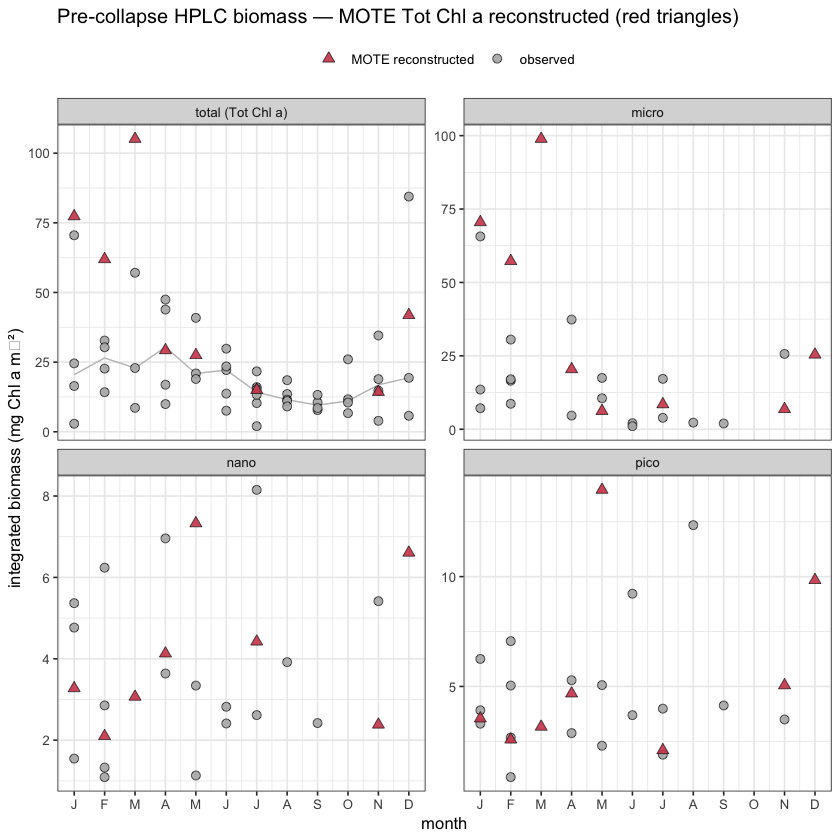

In [11]:
library(tidyverse)
pre_cutoff <- as.Date("2005-01-01")

plotdat <- hplc_int %>%
  mutate(
    recon = source == "MOTE" & !is.finite(Tot_Chl_a_int) & !is.na(DP2),
    TChla_use = ifelse(recon, k * DP2, Tot_Chl_a_int),
    micro_abs = micro * TChla_use,
    nano_abs  = nano  * TChla_use,
    pico_abs  = pico  * TChla_use,
    total_abs = TChla_use,
    mo   = as.integer(format(date, "%m")),
    kind = ifelse(recon, "MOTE reconstructed", "observed")
  ) %>%
  filter(date < pre_cutoff, is.finite(TChla_use))

long <- plotdat %>%
  select(date, mo, kind, micro_abs, nano_abs, pico_abs, total_abs) %>%
  pivot_longer(c(total_abs, micro_abs, nano_abs, pico_abs),
               names_to = "cls", values_to = "abs") %>%
  mutate(cls = recode(cls, total_abs="total (Tot Chl a)", micro_abs="micro",
                      nano_abs="nano", pico_abs="pico"),
         cls = factor(cls, levels=c("total (Tot Chl a)","micro","nano","pico")))

ggplot(long, aes(mo, abs)) +
  geom_line(data = . %>% filter(kind=="observed") %>% group_by(cls, mo) %>%
              summarise(abs = median(abs), .groups="drop"),
            colour="grey75", linewidth=0.4) +              # obs monthly-median guide
  geom_point(aes(fill=kind, shape=kind), size=2.3, colour="black", stroke=0.3, alpha=0.9) +
  scale_shape_manual(values=c(observed=21, `MOTE reconstructed`=24)) +
  scale_fill_manual(values=c(observed="grey70", `MOTE reconstructed`="#D1495B")) +
  facet_wrap(~ cls, scales="free_y", ncol=2) +
  scale_x_continuous(breaks=1:12,
                     labels=c("J","F","M","A","M","J","J","A","S","O","N","D")) +
  labs(x="month", y="integrated biomass (mg Chl a m⁻²)", fill=NULL, shape=NULL,
       title="Pre-collapse HPLC biomass — MOTE Tot Chl a reconstructed (red triangles)") +
  theme_bw(base_size=10) + theme(legend.position="top")

# --- diagnostics ---
cat("\n--- reconstructed MOTE points (pre-era), by month ---\n")
plotdat %>% filter(kind=="MOTE reconstructed") %>%
  transmute(date, mo, depth_cutoff, total_abs, micro_abs, nano_abs, pico_abs) %>%
  arrange(mo) %>% as.data.frame() %>% print(row.names=FALSE)

cat("\n--- observed pre-era envelope by month (for magnitude context) ---\n")
plotdat %>% filter(kind=="observed") %>% group_by(mo) %>%
  summarise(n=n(), total_med=median(total_abs), total_max=max(total_abs),
            micro_med=median(micro_abs), micro_max=max(micro_abs), .groups="drop") %>%
  as.data.frame() %>% print(row.names=FALSE)

In [12]:
chk_mo <- c("11-2000","12-2000","01-2001","02-2001","03-2001","04-2001","05-2001","07-2001")
read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  mutate(time_month = format(as.Date(date), "%m-%Y")) %>%
  filter(time_month %in% chk_mo) %>%
  select(time_month, FN_mmolN_m2_d, depth_cutoff, Temp_C,
         micro_mmolN, nano_mmolN, pico_mmolN) %>%
  print(row.names = FALSE)

 time_month FN_mmolN_m2_d depth_cutoff   Temp_C micro_mmolN nano_mmolN
    11-2000     0.6551116     52.56654 26.00880          NA         NA
    12-2000            NA     32.08337       NA          NA         NA
    01-2001            NA     26.10000       NA          NA         NA
    02-2001     6.8731743     23.40000 21.61434          NA         NA
    03-2001     9.6505125     16.40000 21.55465          NA         NA
    04-2001     3.8043575     36.00000 23.64534          NA         NA
    05-2001     2.3023483     47.00000 23.92767          NA         NA
    07-2001     2.9398454     38.80000 23.09573          NA         NA
 pico_mmolN
         NA
         NA
         NA
         NA
         NA
         NA
         NA
         NA
